In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("/Users/esthercoker/Downloads/insurance.csv")

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.shape

(1338, 7)

In [ ]:
#Description of statistics

print("\nSummary statistics:")
print(df.describe())


Summary statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Cleaning the data

In [ ]:
#Checking for missing data
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#one-hot encoding categorical variables to numerical
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['gender'] = df['sex'].map({'male': 1, 'female': 0})
df['region'] = df['region'].map({
    'northeast': 0,
    'northwest': 1,
    'southeast': 2,
    'southwest': 3})


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

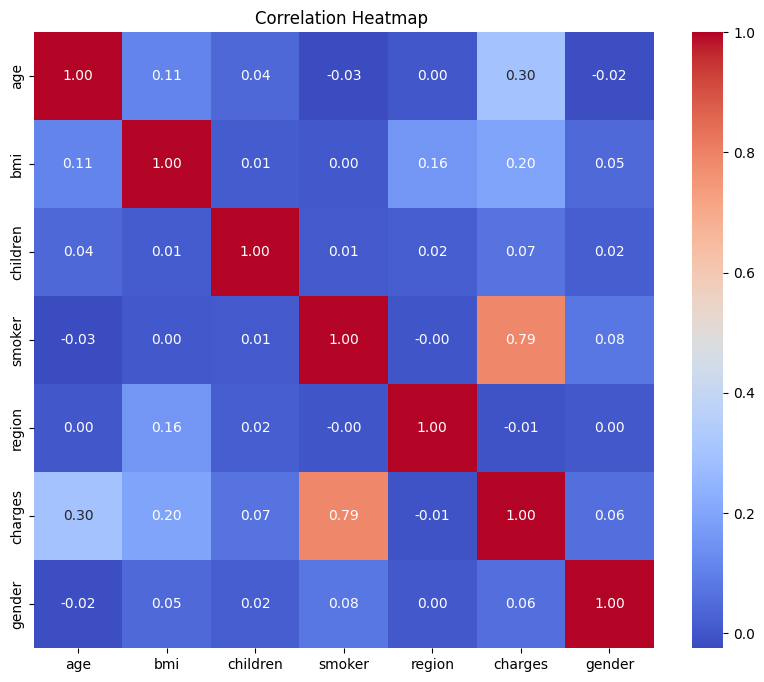

In [ ]:
#Plotting heatmap
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap ")
plt.show()

Visualising the distributions

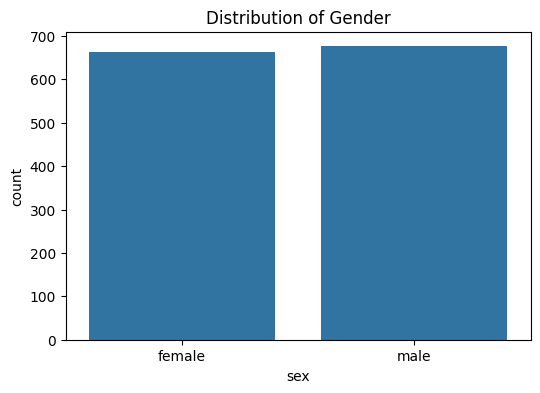

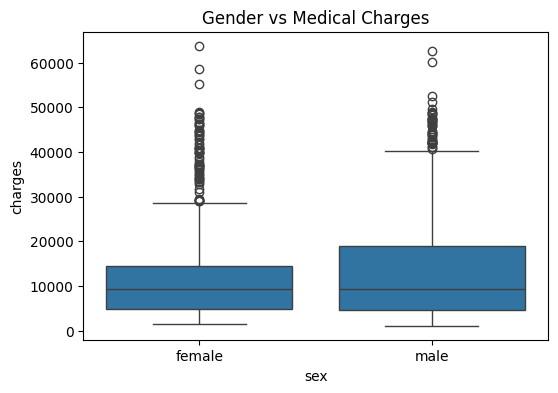

In [ ]:
# Distribution of gender
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df)
plt.title("Distribution of Gender")
plt.show()

# Gender vs charges
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Gender vs Medical Charges")
plt.show()

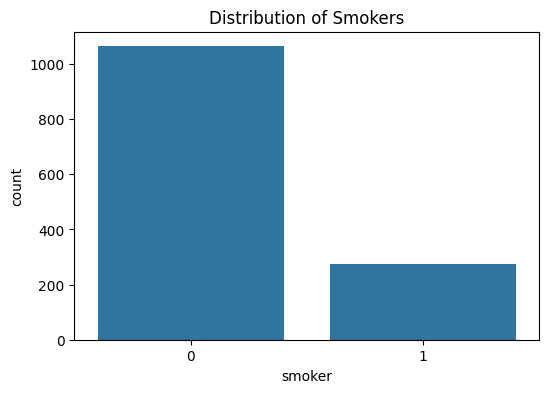

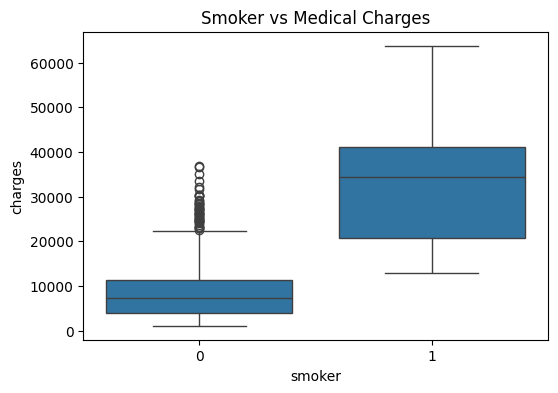

In [ ]:
# Distribution of smoker
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df)
plt.title("Distribution of Smokers")
plt.show()

# Smoker vs charges
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Medical Charges")
plt.show()

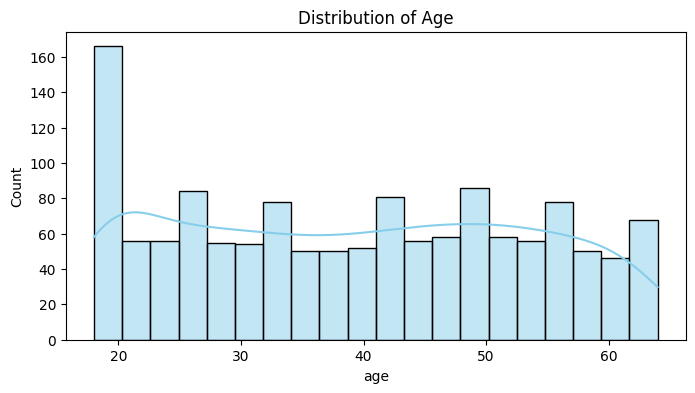

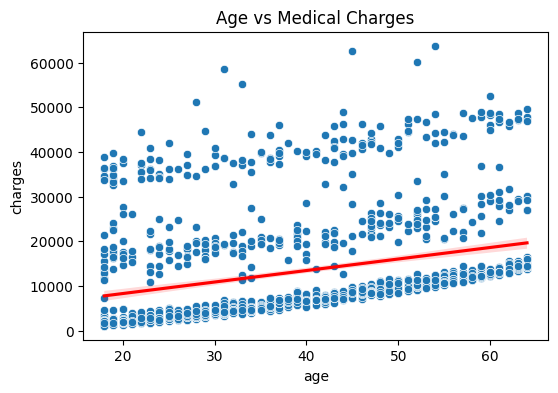

In [ ]:
# Distribution of age
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Age")
plt.show()

# Age vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)
sns.regplot(x='age', y='charges', data=df, scatter=False, color='red')
plt.title("Age vs Medical Charges")
plt.show()

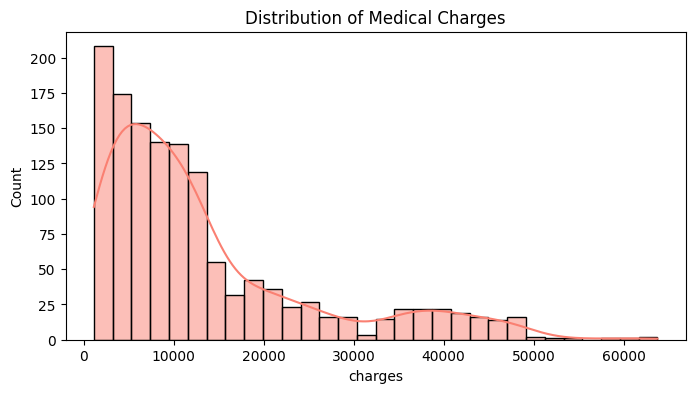

In [ ]:
# Distribution of charges
plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=30, kde=True, color='salmon')
plt.title("Distribution of Medical Charges")
plt.show()

Training the model

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Prediction
y_pred = lr_model.predict(X_test)

Evaluation

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 33635210.43
Root Mean Squared Error: 5799.59
R-squared: 0.78


In [ ]:
lr_model.score(X_test,y_test)

0.7833463107364538

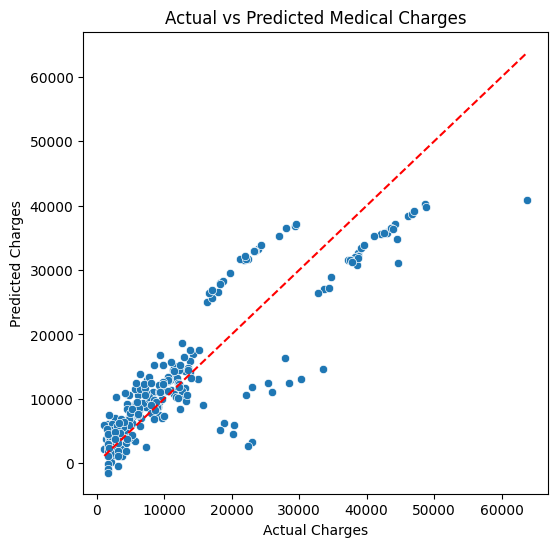

In [ ]:
#Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()